# Full-information Contextual Bandit Benchmark for Risk-Level Classification

이 노트북은 기존 `Dueling DDQN.ipynb`와 같은 데이터 분할/평가 흐름을 사용하되, DDQN의 `next_state`, `target network`, `gamma × future Q` 구조를 제거한 **비용민감형 Neural Contextual Bandit** 버전입니다.

핵심 차이:

- DDQN: `reward + gamma * Q(next_state, next_action)`을 학습
- Contextual Bandit: 현재 context에서 action별 **즉시 보상**을 학습
- 이 버전: 실제 `Risk_Label`이 관측되어 있으므로 action 0/1에 대한 reward target을 모두 계산하는 **full-information reward-regression 방식**을 사용

본 연구의 risk classification 문제에서는 모델의 예측 action이 실제 시장 상태 전이에 영향을 주지 않으므로, DDQN보다 Contextual Bandit이 더 자연스러운 RL benchmark가 될 수 있습니다.

> 전제: `data_selected.csv`의 `Risk_Label`은 이미 t+1 예측용으로 정렬되어 있습니다. 따라서 이 노트북에서는 추가적인 label shift를 수행하지 않습니다.



In [1]:
# ============================================================
# 0. 라이브러리 및 기본 설정
# ============================================================

import random
from pathlib import Path
import copy

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix, classification_report
from sklearn.preprocessing import MinMaxScaler
from itertools import product

# -----------------------------
# 재현성 고정
# -----------------------------
SEED = 1

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")


Device: cpu


In [2]:
# ============================================================
# 1. 데이터 로드 및 시계열 분할
# ============================================================

DATA_PATH = Path("../../data/processed/data_selected.csv")
risk_label_col = "Risk_Label"

# 기존 DDQN 코드와 동일한 파일을 사용합니다.
# Risk_Label은 이미 t+1 예측용으로 정렬되어 있다는 전제입니다.
dat = pd.read_csv(DATA_PATH, index_col=0, parse_dates=True).sort_index()

if risk_label_col not in dat.columns:
    raise ValueError(f"'{risk_label_col}' 컬럼이 데이터에 없습니다.")

def encode_risk_labels(series):
    s = series.copy()

    # 문자열 라벨이면 숫자로 변환
    if pd.api.types.is_object_dtype(s) or pd.api.types.is_string_dtype(s):
        mapping = {
            "Low Risk": 0, "Low risk": 0, "Low": 0, "0": 0,
            "High Risk": 1, "High risk": 1, "High": 1, "1": 1,
        }
        s = s.map(mapping)
        if s.isna().any():
            unknown_values = series[s.isna()].unique()
            raise ValueError(f"알 수 없는 Risk_Label 값이 있습니다: {unknown_values}")

    if s.isna().any():
        raise ValueError("Risk_Label에 결측치가 있습니다. 라벨 생성 단계 또는 dropna 처리를 확인하세요.")

    labels = s.astype(int).to_numpy()
    unique_labels = set(np.unique(labels).tolist())
    if not unique_labels.issubset({0, 1}):
        raise ValueError(f"Risk_Label은 0/1이어야 합니다. 현재 값: {sorted(unique_labels)}")

    return labels

# 수치형 feature만 사용하고 Risk_Label은 제외합니다.
feature_cols = [c for c in dat.select_dtypes(include=[np.number]).columns if c != risk_label_col]
if len(feature_cols) == 0:
    raise ValueError("학습에 사용할 수치형 feature가 없습니다.")

if dat[feature_cols + [risk_label_col]].isna().any().any():
    raise ValueError("feature 또는 Risk_Label에 결측치가 있습니다. 전처리 확인 필요.")

feature_data_raw = dat[feature_cols].to_numpy(dtype=np.float32)
risk_label_data = encode_risk_labels(dat[risk_label_col])

n_steps = len(dat)

# 기존 DDQN과 같은 분할 비율
train_ratio, valid_ratio, test_ratio = 0.45, 0.35, 0.20

n_train = int(n_steps * train_ratio)
n_valid = int(n_steps * valid_ratio)

train_indices = np.arange(0, n_train)
valid_indices = np.arange(n_train, n_train + n_valid)
test_indices = np.arange(n_train + n_valid, n_steps)

train_feature_raw = feature_data_raw[train_indices]
train_label = risk_label_data[train_indices].astype(np.int64)

valid_feature_raw = feature_data_raw[valid_indices]
valid_label = risk_label_data[valid_indices].astype(np.int64)

# 기존 DDQN 코드와 동일하게 validation을 tune/select로 분할
if len(valid_label) < 2:
    raise ValueError("Validation set 길이가 너무 짧아 tune/select 분할이 불가능합니다.")

valid_split_point = int(len(valid_label) * 0.65)

valid_tune_feature_raw = valid_feature_raw[:valid_split_point]
valid_tune_label = valid_label[:valid_split_point]

valid_select_feature_raw = valid_feature_raw[valid_split_point:]
valid_select_label = valid_label[valid_split_point:]

test_feature_raw = feature_data_raw[test_indices]
test_label = risk_label_data[test_indices].astype(np.int64)

# Scaling은 train 기준으로만 fit
scaler = MinMaxScaler()
scaler.fit(train_feature_raw)

train_feature = scaler.transform(train_feature_raw).astype(np.float32)
valid_tune_feature = scaler.transform(valid_tune_feature_raw).astype(np.float32)
valid_select_feature = scaler.transform(valid_select_feature_raw).astype(np.float32)
test_feature = scaler.transform(test_feature_raw).astype(np.float32)

def summarize_class_ratio(name, y):
    n_total = len(y)
    n0 = int((y == 0).sum())
    n1 = int((y == 1).sum())
    r0 = n0 / n_total if n_total > 0 else 0.0
    r1 = n1 / n_total if n_total > 0 else 0.0
    print(f"{name:>7} | n={n_total:4d} | class0={n0:4d} ({r0:.2%}) | class1={n1:4d} ({r1:.2%}) | c1/c0={n1 / max(n0, 1):.4f}")
    if n0 == 0 or n1 == 0:
        raise ValueError(f"{name} set에 클래스 0 또는 1이 없습니다. split 비율 또는 기간을 조정하세요.")

print("Class Ratio Summary")
summarize_class_ratio("Train", train_label)
summarize_class_ratio("ValTune", valid_tune_label)
summarize_class_ratio("ValSel", valid_select_label)
summarize_class_ratio("Test", test_label)

# reward 계산에 사용할 클래스 비율은 원본 train 기준으로 고정
n_low_train = int((train_label == 0).sum())
n_high_train = int((train_label == 1).sum())
rho = n_high_train / max(n_low_train, 1)

state_dim = len(feature_cols)
action_dim = 2

print("\n" + "=" * 70)
print("Data Split Information")
print("=" * 70)
print(f"Total samples: {n_steps}")
print(f"Number of features: {state_dim}")
print(f"Train: {len(train_label)}")
print(f"Valid Tune: {len(valid_tune_label)}")
print(f"Valid Select: {len(valid_select_label)}")
print(f"Test: {len(test_label)}")
print(f"Reward rho = n_high / n_low = {rho:.4f}")
print("=" * 70)




Class Ratio Summary
  Train | n=1848 | class0=1665 (90.10%) | class1= 183 (9.90%) | c1/c0=0.1099
ValTune | n= 934 | class0= 842 (90.15%) | class1=  92 (9.85%) | c1/c0=0.1093
 ValSel | n= 503 | class0= 433 (86.08%) | class1=  70 (13.92%) | c1/c0=0.1617
   Test | n= 823 | class0= 732 (88.94%) | class1=  91 (11.06%) | c1/c0=0.1243

Data Split Information
Total samples: 4108
Number of features: 10
Train: 1848
Valid Tune: 934
Valid Select: 503
Test: 823
Reward rho = n_high / n_low = 0.1099


In [3]:
# ============================================================
# 2. 평가 지표 및 Reward 정의
# ============================================================

def compute_gmean(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0  # class 1 recall
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0  # class 0 recall
    gmean = float(np.sqrt(sensitivity * specificity))

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    f1 = 2 * precision * sensitivity / (precision + sensitivity) if (precision + sensitivity) > 0 else 0.0
    accuracy = (tp + tn) / max(tp + tn + fp + fn, 1)

    return {
        "gmean": gmean,
        "sensitivity": sensitivity,
        "specificity": specificity,
        "precision": precision,
        "f1": f1,
        "accuracy": accuracy,
        "cm": cm,
    }

def compute_reward_for_action(action, actual_label, rho, fn_penalty=1.0):
    """
    Cost-sensitive reward.

    actual_label = 0:
        action 0 -> TN -> +rho
        action 1 -> FP -> -rho

    actual_label = 1:
        action 1 -> TP -> +1
        action 0 -> FN -> -fn_penalty

    fn_penalty를 1보다 크게 두면 High risk를 놓치는 오류를 더 강하게 벌점화합니다.
    """
    action = int(action)
    actual_label = int(actual_label)

    if actual_label == 0:
        return rho if action == 0 else -rho
    else:
        return 1.0 if action == 1 else -float(fn_penalty)

def reward_vector_from_labels(labels, rho, fn_penalty=1.0):
    """
    각 관측치에 대해 action 0/1을 선택했을 때의 즉시 reward target을 계산합니다.
    full-information contextual bandit 학습이나 진단용으로 사용할 수 있습니다.
    """
    labels = np.asarray(labels).astype(int)
    rewards = np.zeros((len(labels), 2), dtype=np.float32)

    # actual low risk
    low_mask = labels == 0
    rewards[low_mask, 0] = rho
    rewards[low_mask, 1] = -rho

    # actual high risk
    high_mask = labels == 1
    rewards[high_mask, 0] = -float(fn_penalty)
    rewards[high_mask, 1] = 1.0

    return rewards


In [4]:
# ============================================================
# 3. Neural Contextual Bandit 모델 정의
# ============================================================

class BanditQNetwork(nn.Module):
    """
    현재 context x_t를 입력받아 action별 expected immediate reward Q(x, a)를 출력합니다.
    DDQN과 달리 next_state나 target network를 사용하지 않습니다.
    """
    def __init__(self, state_dim, action_dim=2, hidden_dims=(96, 64), dropout=0.0):
        super().__init__()

        layers = []
        in_dim = state_dim

        for h in hidden_dims:
            layers.append(nn.Linear(in_dim, h))
            layers.append(nn.ReLU())
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            in_dim = h

        layers.append(nn.Linear(in_dim, action_dim))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


class NeuralContextualBandit:
    """
    Full-information Neural Contextual Bandit.

    학습 방식:
    1. 현재 context x_t를 입력받아 action별 Q(x, a)를 출력
    2. 실제 label을 이용해 action 0/1 각각의 reward target을 계산
    3. Q(x, 0), Q(x, 1)이 각 reward target에 가까워지도록 MSE 업데이트

    DDQN과 다른 점:
    - gamma 없음
    - next_state 없음
    - target network 없음
    - Bellman target 없음
    - epsilon-greedy action sampling 없음
    - 즉시보상 reward target만 학습
    """
    def __init__(
        self,
        state_dim,
        action_dim=2,
        hidden_dims=(96, 64),
        dropout=0.0,
        lr=1e-4,
        batch_size=64,
    ):
        self.action_dim = action_dim
        self.batch_size = batch_size

        self.q_net = BanditQNetwork(
            state_dim=state_dim,
            action_dim=action_dim,
            hidden_dims=hidden_dims,
            dropout=dropout,
        ).to(device)

        self.optimizer = optim.Adam(self.q_net.parameters(), lr=lr)

    def predict(self, features):
        self.q_net.eval()
        preds = []

        with torch.no_grad():
            for start in range(0, len(features), 1024):
                batch = torch.FloatTensor(features[start:start + 1024]).to(device)
                q_values = self.q_net(batch)
                preds.extend(torch.argmax(q_values, dim=1).cpu().numpy().tolist())

        return np.array(preds, dtype=np.int64)

    def predict_q_values(self, features):
        self.q_net.eval()
        q_list = []

        with torch.no_grad():
            for start in range(0, len(features), 1024):
                batch = torch.FloatTensor(features[start:start + 1024]).to(device)
                q_values = self.q_net(batch)
                q_list.append(q_values.cpu().numpy())

        return np.vstack(q_list)

    def update_batch(self, states, labels, rho, fn_penalty=1.0):
        states = np.asarray(states, dtype=np.float32)
        labels = np.asarray(labels, dtype=np.int64)

        states_t = torch.FloatTensor(states).to(device)

        reward_targets = reward_vector_from_labels(
            labels,
            rho=rho,
            fn_penalty=fn_penalty,
        )
        rewards_t = torch.FloatTensor(reward_targets).to(device)

        q_values = self.q_net(states_t)
        loss = F.mse_loss(q_values, rewards_t)

        self.optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(self.q_net.parameters(), max_norm=10.0)
        self.optimizer.step()

        with torch.no_grad():
            greedy_actions = torch.argmax(q_values, dim=1).cpu().numpy()

        chosen_rewards = np.array([
            compute_reward_for_action(a, y, rho=rho, fn_penalty=fn_penalty)
            for a, y in zip(greedy_actions, labels)
        ], dtype=np.float32)

        return float(loss.item()), float(chosen_rewards.mean())




In [5]:
# ============================================================
# 4. Contextual Bandit 학습 함수
# ============================================================

def evaluate_bandit(agent, features, labels):
    preds = agent.predict(features)
    metrics = compute_gmean(labels, preds)
    return metrics, preds


def train_contextual_bandit(
    train_x,
    train_y,
    eval_x,
    eval_y,
    params,
    rho,
    max_epochs=200,
    patience=25,
    min_epochs=40,
    eval_every=5,
    seed=SEED,
    verbose=True,
):
    set_seed(seed)

    agent = NeuralContextualBandit(
        state_dim=state_dim,
        action_dim=action_dim,
        hidden_dims=params["hidden_dims"],
        dropout=params["dropout"],
        lr=params["lr"],
        batch_size=params["batch_size"],
    )

    best_gmean = -1.0
    best_state_dict = None
    best_epoch = 0
    patience_counter = 0

    history = []
    n = len(train_y)

    for epoch in range(1, max_epochs + 1):
        # 매 epoch마다 train sample 순서를 섞어 학습
        indices = np.random.permutation(n)

        epoch_losses = []
        epoch_rewards = []

        for start in range(0, n, params["batch_size"]):
            batch_idx = indices[start:start + params["batch_size"]]
            if len(batch_idx) == 0:
                continue

            loss, mean_reward = agent.update_batch(
                train_x[batch_idx],
                train_y[batch_idx],
                rho=rho,
                fn_penalty=params["fn_penalty"],
            )
            epoch_losses.append(loss)
            epoch_rewards.append(mean_reward)

        if epoch % eval_every == 0:
            metrics, _ = evaluate_bandit(agent, eval_x, eval_y)
            gmean = metrics["gmean"]

            history.append({
                "epoch": epoch,
                "train_loss": float(np.mean(epoch_losses)) if epoch_losses else np.nan,
                "train_reward": float(np.mean(epoch_rewards)) if epoch_rewards else np.nan,
                "eval_gmean": metrics["gmean"],
                "eval_sensitivity": metrics["sensitivity"],
                "eval_specificity": metrics["specificity"],
                "eval_precision": metrics["precision"],
                "eval_f1": metrics["f1"],
                "eval_accuracy": metrics["accuracy"],
            })

            if gmean > best_gmean:
                best_gmean = gmean
                best_epoch = epoch
                best_state_dict = copy.deepcopy(agent.q_net.state_dict())
                patience_counter = 0
            else:
                patience_counter += 1

            if verbose and epoch % 20 == 0:
                print(
                    f"  Epoch {epoch:3d} | "
                    f"Eval G-mean: {metrics['gmean']:.4f} "
                    f"(Sens: {metrics['sensitivity']:.4f}, Spec: {metrics['specificity']:.4f}) | "
                    f"Best: {best_gmean:.4f}"
                )

            if epoch >= min_epochs and patience_counter >= patience:
                break

    if best_state_dict is not None:
        agent.q_net.load_state_dict(best_state_dict)

    return agent, best_gmean, best_epoch, pd.DataFrame(history)




In [6]:
# ============================================================
# 5. Hyperparameter Grid Search
# ============================================================

# Full-information contextual bandit이므로 epsilon/epsilon_decay는 사용하지 않습니다.
# 조합 수: 2 * 2 * 2 * 2 * 3 = 48개
param_grid = {
    "hidden_dims": [(96, 64), (64, 32)],
    "dropout": [0.0, 0.1],
    "lr": [1e-4, 5e-4],
    "batch_size": [32, 64],
    # FN penalty는 High risk를 Low risk로 놓치는 오류를 얼마나 강하게 벌점화할지 결정합니다.
    # sensitivity가 너무 낮으면 1.5~2.0이 유리할 수 있고,
    # specificity가 너무 무너지면 1.0이 더 안정적일 수 있습니다.
    "fn_penalty": [1.0, 1.5, 2.0],
}

param_names = list(param_grid.keys())
param_combinations = list(product(*param_grid.values()))

print("\n" + "=" * 80)
print(f"CONTEXTUAL BANDIT GRID SEARCH (Total: {len(param_combinations)} combinations)")
print("=" * 80)

grid_search_results = []
best_overall_select_gmean = -1.0
best_overall_params = None
best_overall_agent_state = None

for idx, values in enumerate(param_combinations):
    params = dict(zip(param_names, values))

    print(
        f"\n[{idx+1}/{len(param_combinations)}] "
        f"hidden={params['hidden_dims']}, dropout={params['dropout']}, "
        f"lr={params['lr']:.0e}, "
        f"bs={params['batch_size']}, fn_penalty={params['fn_penalty']}"
    )

    # 1) train으로 학습하면서 valid_tune으로 checkpoint 선택
    agent_tune, best_tune_gmean, best_tune_epoch, tune_history = train_contextual_bandit(
        train_feature,
        train_label,
        valid_tune_feature,
        valid_tune_label,
        params=params,
        rho=rho,
        max_epochs=200,
        patience=25,
        min_epochs=40,
        eval_every=5,
        seed=SEED,
        verbose=True,
    )

    # 2) best tune checkpoint를 valid_select에서 평가하여 hyperparameter 선택
    select_metrics, select_preds = evaluate_bandit(agent_tune, valid_select_feature, valid_select_label)

    result = {
        "params": params,
        "best_tune_gmean": best_tune_gmean,
        "best_tune_epoch": best_tune_epoch,
        "select_gmean": select_metrics["gmean"],
        "select_sensitivity": select_metrics["sensitivity"],
        "select_specificity": select_metrics["specificity"],
        "select_precision": select_metrics["precision"],
        "select_f1": select_metrics["f1"],
        "select_accuracy": select_metrics["accuracy"],
    }
    grid_search_results.append(result)

    print(
        f"  -> Select G-mean: {select_metrics['gmean']:.4f} "
        f"(Sens: {select_metrics['sensitivity']:.4f}, Spec: {select_metrics['specificity']:.4f})"
    )

    if select_metrics["gmean"] > best_overall_select_gmean:
        best_overall_select_gmean = select_metrics["gmean"]
        best_overall_params = params.copy()
        best_overall_agent_state = copy.deepcopy(agent_tune.q_net.state_dict())

grid_search_results = sorted(grid_search_results, key=lambda x: x["select_gmean"], reverse=True)

print("\n" + "=" * 80)
print("TOP 5 CONTEXTUAL BANDIT HYPERPARAMETERS")
print("=" * 80)
for i, result in enumerate(grid_search_results[:5]):
    print(
        f"{i+1}. Select G-mean: {result['select_gmean']:.4f} | "
        f"Tune Best: {result['best_tune_gmean']:.4f} @ epoch {result['best_tune_epoch']} | "
        f"Params: {result['params']}"
    )

print("\n" + "=" * 80)
print("BEST CONTEXTUAL BANDIT HYPERPARAMETERS")
print("=" * 80)
for k, v in best_overall_params.items():
    print(f"{k}: {v}")
print(f"Best Selection G-mean: {best_overall_select_gmean:.4f}")
print("=" * 80)

# grid 결과 저장
grid_df = pd.DataFrame([
    {
        "rank": i + 1,
        "select_gmean": r["select_gmean"],
        "select_sensitivity": r["select_sensitivity"],
        "select_specificity": r["select_specificity"],
        "select_precision": r["select_precision"],
        "select_f1": r["select_f1"],
        "select_accuracy": r["select_accuracy"],
        "best_tune_gmean": r["best_tune_gmean"],
        "best_tune_epoch": r["best_tune_epoch"],
        "hidden_dims": str(r["params"]["hidden_dims"]),
        "dropout": r["params"]["dropout"],
        "lr": r["params"]["lr"],
        "batch_size": r["params"]["batch_size"],
        "fn_penalty": r["params"]["fn_penalty"],
    }
    for i, r in enumerate(grid_search_results)
])
grid_df.to_csv("contextual_bandit_grid_results.csv", index=False)
display(grid_df.head(10))





CONTEXTUAL BANDIT GRID SEARCH (Total: 48 combinations)

[1/48] hidden=(96, 64), dropout=0.0, lr=1e-04, bs=32, fn_penalty=1.0
  Epoch  20 | Eval G-mean: 0.6709 (Sens: 0.6413, Spec: 0.7019) | Best: 0.6749
  Epoch  40 | Eval G-mean: 0.6931 (Sens: 0.6630, Spec: 0.7245) | Best: 0.6931
  Epoch  60 | Eval G-mean: 0.6511 (Sens: 0.5543, Spec: 0.7648) | Best: 0.6942
  Epoch  80 | Eval G-mean: 0.6608 (Sens: 0.6087, Spec: 0.7173) | Best: 0.6942
  Epoch 100 | Eval G-mean: 0.6597 (Sens: 0.5978, Spec: 0.7280) | Best: 0.6942
  Epoch 120 | Eval G-mean: 0.6736 (Sens: 0.5978, Spec: 0.7589) | Best: 0.6942
  Epoch 140 | Eval G-mean: 0.6500 (Sens: 0.5326, Spec: 0.7933) | Best: 0.6942
  Epoch 160 | Eval G-mean: 0.6139 (Sens: 0.4457, Spec: 0.8456) | Best: 0.6942
  -> Select G-mean: 0.6518 (Sens: 0.8286, Spec: 0.5127)

[2/48] hidden=(96, 64), dropout=0.0, lr=1e-04, bs=32, fn_penalty=1.5
  Epoch  20 | Eval G-mean: 0.6571 (Sens: 0.8043, Spec: 0.5368) | Best: 0.6571
  Epoch  40 | Eval G-mean: 0.6719 (Sens: 0.728

,rank,select_gmean,select_sensitivity,select_specificity,select_precision,select_f1,select_accuracy,best_tune_gmean,best_tune_epoch,hidden_dims,dropout,lr,batch_size,fn_penalty
0,1,0.671816,0.814286,0.554273,0.228000,0.356250,0.590457,0.689526,70,"(96, 64)",0.1,0.0001,64,1.0
1,2,0.653241,0.828571,0.515012,0.216418,0.343195,0.558648,0.683849,200,"(64, 32)",0.0,0.0005,64,2.0
2,3,0.651775,0.828571,0.512702,0.215613,0.342183,0.556660,0.694210,45,"(96, 64)",0.0,0.0001,32,1.0
3,4,0.649036,0.800000,0.526559,0.214559,0.338369,0.564612,0.681144,160,"(64, 32)",0.0,0.0001,32,2.0
4,5,0.640129,0.771429,0.531178,0.210117,0.330275,0.564612,0.688843,125,"(64, 32)",0.0,0.0005,32,2.0
5,6,0.639923,0.828571,0.494226,0.209386,0.334294,0.540755,0.688346,75,"(96, 64)",0.1,0.0001,32,1.0
6,7,0.638814,0.814286,0.501155,0.208791,0.332362,0.544732,0.681713,145,"(64, 32)",0.1,0.0005,64,1.5
7,8,0.638736,0.771429,0.528868,0.209302,0.329268,0.562624,0.683377,80,"(96, 64)",0.0,0.0005,32,1.5
8,9,0.638426,0.828571,0.491917,0.208633,0.333333,0.538767,0.680746,20,"(96, 64)",0.0,0.0005,64,1.0
9,10,0.634695,0.785714,0.512702,0.206767,0.327381,0.550696,0.689948,130,"(64, 32)",0.0,0.0005,32,1.5


In [7]:
# ============================================================
# 6. 최적 파라미터로 최종 학습 및 Test 평가
# ============================================================

print("\nTraining final Contextual Bandit with best hyperparameters...")

# DDQN 코드와 비교를 맞추기 위해 기본값은 train만 사용합니다.
# 더 많은 학습 데이터를 쓰고 싶으면 True로 바꾸세요.
USE_TUNE_IN_FINAL_TRAIN = False

if USE_TUNE_IN_FINAL_TRAIN:
    final_train_feature = np.vstack([train_feature, valid_tune_feature])
    final_train_label = np.concatenate([train_label, valid_tune_label])
    print("Final train data = train + valid_tune")
else:
    final_train_feature = train_feature
    final_train_label = train_label
    print("Final train data = train only")

final_agent, final_best_valid_gmean, final_best_epoch, final_history = train_contextual_bandit(
    final_train_feature,
    final_train_label,
    valid_select_feature,
    valid_select_label,
    params=best_overall_params,
    rho=rho,
    max_epochs=250,
    patience=30,
    min_epochs=40,
    eval_every=5,
    seed=SEED,
    verbose=True,
)

print("\n최종 학습 완료")
print(f"Best valid_select checkpoint: epoch={final_best_epoch}, valid_select_gmean={final_best_valid_gmean:.4f}")

# -----------------------------
# Validation Select 평가
# -----------------------------
valid_metrics, valid_predictions = evaluate_bandit(final_agent, valid_select_feature, valid_select_label)
cm_valid = valid_metrics["cm"]

# -----------------------------
# Test 평가
# -----------------------------
test_metrics, test_predictions = evaluate_bandit(final_agent, test_feature, test_label)
cm_test = test_metrics["cm"]

print("\n" + "=" * 70)
print("VALIDATION SELECT SET - Contextual Bandit 성능")
print("=" * 70)
print(f"G-mean: {valid_metrics['gmean']:.4f}")
print(f"Sensitivity: {valid_metrics['sensitivity']:.4f}")
print(f"Specificity: {valid_metrics['specificity']:.4f}")
print(f"Precision: {valid_metrics['precision']:.4f}")
print(f"F1-score: {valid_metrics['f1']:.4f}")
print(f"Accuracy: {valid_metrics['accuracy']:.4f}")
print("Confusion Matrix:")
print(cm_valid)

print("\n" + "=" * 70)
print("TEST SET - Contextual Bandit 최종 성능")
print("=" * 70)
print(f"G-mean: {test_metrics['gmean']:.4f}")
print(f"Sensitivity: {test_metrics['sensitivity']:.4f}")
print(f"Specificity: {test_metrics['specificity']:.4f}")
print(f"Precision: {test_metrics['precision']:.4f}")
print(f"F1-score: {test_metrics['f1']:.4f}")
print(f"Accuracy: {test_metrics['accuracy']:.4f}")
print("Confusion Matrix:")
print(cm_test)

print("\n분류 리포트:")
print(
    classification_report(
        test_label,
        test_predictions,
        labels=[0, 1],
        target_names=["Class 0 (Low risk)", "Class 1 (High risk)"],
        zero_division=0,
    )
)

print("\n" + "=" * 70)
print("VALIDATION vs TEST")
print("=" * 70)
print(f"Valid G-mean: {valid_metrics['gmean']:.4f}")
print(f"Test  G-mean: {test_metrics['gmean']:.4f}")
print(f"Difference (Valid - Test): {valid_metrics['gmean'] - test_metrics['gmean']:.4f}")
print("=" * 70)





Training final Contextual Bandit with best hyperparameters...
Final train data = train only
  Epoch  20 | Eval G-mean: 0.6054 (Sens: 0.7857, Spec: 0.4665) | Best: 0.6302
  Epoch  40 | Eval G-mean: 0.6566 (Sens: 0.7714, Spec: 0.5589) | Best: 0.6566
  Epoch  60 | Eval G-mean: 0.6777 (Sens: 0.8286, Spec: 0.5543) | Best: 0.6777
  Epoch  80 | Eval G-mean: 0.6278 (Sens: 0.8286, Spec: 0.4758) | Best: 0.6777
  Epoch 100 | Eval G-mean: 0.6648 (Sens: 0.8143, Spec: 0.5427) | Best: 0.6777
  Epoch 120 | Eval G-mean: 0.6562 (Sens: 0.8143, Spec: 0.5289) | Best: 0.6806
  Epoch 140 | Eval G-mean: 0.6605 (Sens: 0.8143, Spec: 0.5358) | Best: 0.6806
  Epoch 160 | Eval G-mean: 0.6852 (Sens: 0.7286, Spec: 0.6443) | Best: 0.6852
  Epoch 180 | Eval G-mean: 0.6530 (Sens: 0.7857, Spec: 0.5427) | Best: 0.6852
  Epoch 200 | Eval G-mean: 0.6698 (Sens: 0.7143, Spec: 0.6282) | Best: 0.6852
  Epoch 220 | Eval G-mean: 0.6438 (Sens: 0.7571, Spec: 0.5473) | Best: 0.6852
  Epoch 240 | Eval G-mean: 0.6429 (Sens: 0.7714, 

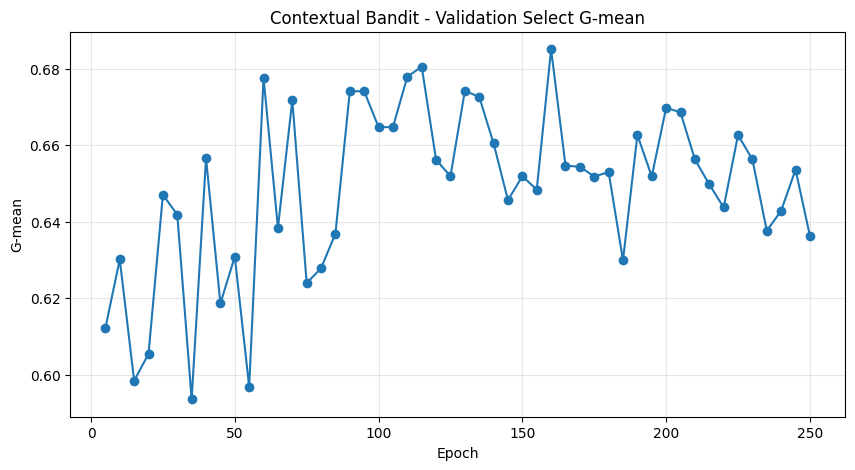

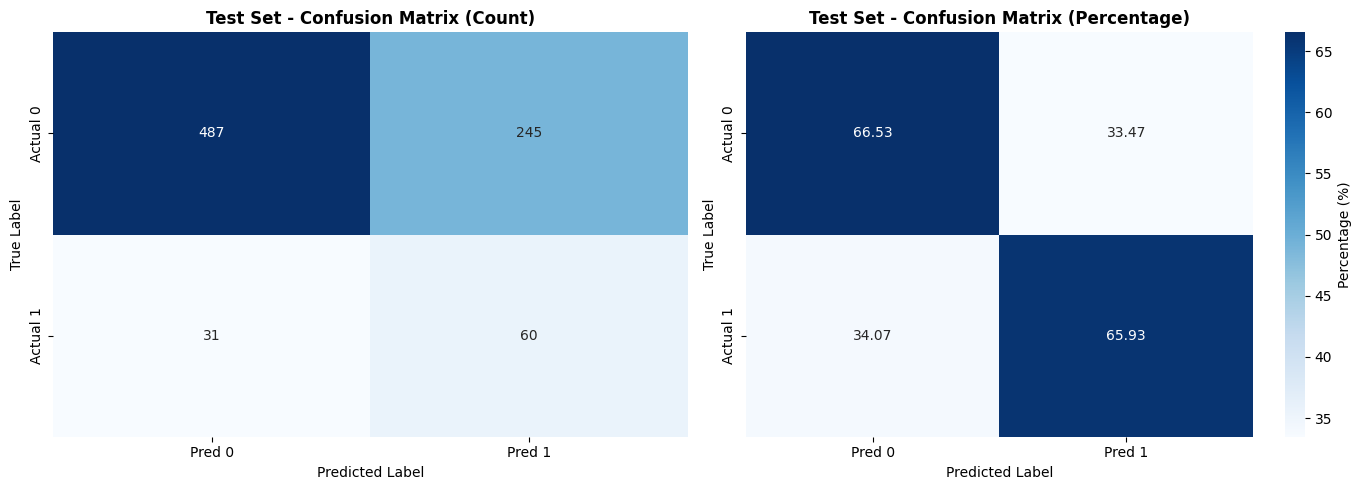

In [8]:
# ============================================================
# 7. 시각화
# ============================================================

# 학습 곡선
if len(final_history) > 0:
    plt.figure(figsize=(10, 5))
    plt.plot(final_history["epoch"], final_history["eval_gmean"], marker="o")
    plt.title("Contextual Bandit - Validation Select G-mean")
    plt.xlabel("Epoch")
    plt.ylabel("G-mean")
    plt.grid(True, alpha=0.3)
    plt.show()

# Test confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]
sns.heatmap(
    cm_test,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    ax=ax1,
    xticklabels=["Pred 0", "Pred 1"],
    yticklabels=["Actual 0", "Actual 1"],
)
ax1.set_title("Test Set - Confusion Matrix (Count)", fontsize=12, fontweight="bold")
ax1.set_ylabel("True Label")
ax1.set_xlabel("Predicted Label")

cm_test_row_sums = cm_test.sum(axis=1, keepdims=True)
cm_test_percent = np.divide(
    cm_test.astype(float),
    cm_test_row_sums,
    out=np.zeros_like(cm_test, dtype=float),
    where=cm_test_row_sums != 0,
) * 100

ax2 = axes[1]
sns.heatmap(
    cm_test_percent,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    cbar=True,
    ax=ax2,
    xticklabels=["Pred 0", "Pred 1"],
    yticklabels=["Actual 0", "Actual 1"],
    cbar_kws={"label": "Percentage (%)"},
)
ax2.set_title("Test Set - Confusion Matrix (Percentage)", fontsize=12, fontweight="bold")
ax2.set_ylabel("True Label")
ax2.set_xlabel("Predicted Label")

plt.tight_layout()
plt.show()


In [9]:
# ============================================================
# 8. 예측 결과 저장
# ============================================================

# Test 예측 저장
test_dates = dat.index[test_indices]
test_predicted_actions_df = pd.DataFrame({
    "Date": test_dates,
    "Predicted_Action": test_predictions,
    "True_Label": test_label,
})

test_output_path = "contextual_bandit_test_predictions.csv"
test_predicted_actions_df.to_csv(test_output_path, index=False)
print(f"Test 예측 결과 저장 완료: {test_output_path}")
display(test_predicted_actions_df.head())

# 전체 데이터 예측 저장
# 주의: train/validation 구간은 out-of-sample 성능 평가용이 아니라 진단/시각화용입니다.
full_feature_raw = dat[feature_cols].to_numpy(dtype=np.float32)
full_feature = scaler.transform(full_feature_raw).astype(np.float32)

all_predictions = final_agent.predict(full_feature)

all_predicted_actions_df = pd.DataFrame({
    "Date": dat.index,
    "Predicted_Action": all_predictions,
})

all_output_path = "contextual_bandit_all_predictions.csv"
all_predicted_actions_df.to_csv(all_output_path, index=False)
print(f"전체 데이터 예측 결과 저장 완료: {all_output_path}")
display(all_predicted_actions_df.head())


Test 예측 결과 저장 완료: contextual_bandit_test_predictions.csv


,Date,Predicted_Action,True_Label
0,2022-10-14,1,0
1,2022-10-17,0,0
2,2022-10-18,0,0
3,2022-10-19,1,0
4,2022-10-20,1,0


전체 데이터 예측 결과 저장 완료: contextual_bandit_all_predictions.csv


,Date,Predicted_Action
0,2009-04-17,0
1,2009-04-20,1
2,2009-04-21,1
3,2009-04-22,1
4,2009-04-23,0


## 결과 해석 메모

Contextual Bandit 결과를 DDQN과 비교할 때는 아래를 중심으로 보면 됩니다.

1. **Test G-mean**
   - DDQN보다 높으면 전체 균형 성능이 더 좋다는 의미입니다.

2. **Sensitivity**
   - High risk를 얼마나 잘 잡는지입니다.
   - VaR 위반 방지 목적에서는 특히 중요합니다.

3. **Specificity**
   - Low risk를 얼마나 잘 유지하는지입니다.
   - 너무 낮으면 High risk를 과하게 남발한다는 뜻입니다.

4. **Valid-Test gap**
   - validation보다 test가 크게 떨어지면 과적합 가능성이 큽니다.

5. **fn_penalty**
   - 1.0보다 큰 값이 선택되면 High risk 미탐지, 즉 FN을 더 강하게 벌점화하는 설정이 validation에서 유리했다는 뜻입니다.
   - sensitivity는 올라가고 specificity는 내려갈 수 있으므로 G-mean과 confusion matrix를 함께 봐야 합니다.

보고서용 표현 예시:

> 본 연구의 위험수준 예측 문제에서는 모델의 action이 실제 시장 상태 전이에 영향을 주지 않는다. 따라서 장기 누적보상을 학습하는 DDQN과 함께, 현재 시장 정보(context)에 대한 즉시보상 중심의 Contextual Bandit 모형을 추가로 적용하였다. Contextual Bandit은 Low/High risk 예측을 action으로 정의하고, 실제 위험 라벨을 이용해 action별 reward target을 구성하는 full-information 방식으로 학습하였다. 또한 High risk 미탐지 오류에 비용을 부여하는 reward 구조를 통해 불균형 위험분류 문제를 반영하였다.

